# Concept Bottleneck Model from Text-to-Concept for Video

_Authors: E. Cabalé, H. Naranjo and R. Paganini_

This notebook is created to design, train and evaluate a concept bottleneck model using the Text-to-concept alignment.

## Imports and initiation

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
import numpy as np
import torch
from tqdm import tqdm
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from concept_bottleneck_model import ConceptBottleneckModel, CBMTrainer
from video_utils import load_k400_split, DivideBy255, CTHWToTCHW, ToTensorTuple, VideoMAETTCTWrapper
from train_video_aligner import SizedLabeledVideoDataset
from transformers import VideoMAEModel
from TextToConcept import TextToConcept

# Pytorchvideo for video processing and loading
# git clone https://github.com/facebookresearch/pytorchvideo.git
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/rodrigopaganini/master/xai/project/Text-to-concept/ViCLIP/viclip_text.py:4: UserWarning: pkg_res

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## Loading Vision Model

### VideoMAE
In this part, we load VideoMAE model.
In order to use ``TextToConcept`` framework, model should implement these functions/attributes:
+ ``forward_features(x)`` that takes a tensor as the input and outputs the representation (features) of input $x$ when it is passed through the model.
+ ``get_normalizer`` should be the normalizer that the models uses to preprocess the input. e.g., Resnet18, uses standard ImageNet normalizer.
+ Attribute ``has_normalizer`` should be `True` when normalizer is need for the model.

In our work, we achieved this by means of the wrapper `VideoMAETTCTWrapper`.

In [3]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
videomae_model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae_model = videomae_model.to(device)

model = VideoMAETTCTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 6058.80it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED |  

### Text-to-Concept

Here, we instantiate Text-to-concept to obtain automatic concept labels for the CBM.

This is acheived by exploiting the fact that TTC allows us to compare VideoMAE features with ViCLIP prompts through the alignment. Thus, we can obtain similarity scores (i.e. cosine distance) between concepts and a given video input. Next, we can train a CBM as a simple linear model that takes these similarities as inputs and predicts the corresponding video class.

In [4]:
text_to_concept = TextToConcept(model, model_name='videomae', input_type='video')

In this notebook we load a trained Linear Aligner. If you wish to train your own aligner, please run  [train_linear_aligner](train_linear_aligner.py).

This aligner in particular was constructed by aligning VideoMAE features of the [Kinetics-400 (5%)](https://www.kaggle.com/datasets/rohanmallick/kinetics-train-5per) dataset to those of ViCLIP.

In [5]:
path = 'pretrained_aligners/videomae_base_aligner_k400.pth'
text_to_concept.load_linear_aligner(path, device=device)
text_to_concept.device = torch.device(device)

## Dataset: Kinetics 400 subset

To perform the CBM task, we take a subset of classes from the Kinetics-400 (5%). This is done due to the fact that, with imperfect alignmente between the vision and ViCLIP model, too many classes results in a very noisy and dificult task.

Preprocessing matches what was used during training ([train_video_aligner.py](train_video_aligner.py)):
- Take clips of 10 s duration (always captures the full duration of the video).
- Samples 16 frames uniformly within the clip, to fit VideoMAE input tensor shape. Note that in a 10 s video, this involves roughly 1 frame every $0.6$ s, which is good enough to capture coarse events in the video for classification. Provided the dataset and datasets classes, this is a reasonable choice: fine-grain events are normally not relevant, and it is good to discard irrelevant sections of the video.
- Resizes and crops by 224 to match VideoMAE input tensor shape, and normalization.

In [6]:
# Dataset paths
K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

# Classes to keep from Kinetics-400
CLASSES_TO_KEEP = ['playing violin', 'playing cello', 'bowling', 'brushing teeth',
       'swimming backstroke', 'swimming butterfly stroke']

# -----------------------------
clip_sampler = UniformClipSampler(clip_duration=10.0)
preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

def filter_labeled_video_paths_by_labels(labeled_video_paths, allowed_labels, class_to_idx=None):
    if class_to_idx is not None:
        allowed_labels = {
            class_to_idx[label] if isinstance(label, str) else int(label)
            for label in allowed_labels
        }
    else:
        allowed_labels = {int(label) for label in allowed_labels}

    filtered_vids = [
        (video_path, info)
        for video_path, info in labeled_video_paths
        if info["label"] in allowed_labels
    ]
    new_class_to_index = {label: idx for idx, label in enumerate(sorted(allowed_labels))}

    return filtered_vids, new_class_to_index

with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

labeled_video_paths = load_k400_split(
    "train",
    K400_ROOT / "train/1",
    class_to_idx=class_to_idx
)

subset_paths, map_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

subset_class_names = [None] * len(map_old_to_new_index)
for class_name, old_idx in class_to_idx.items():
    if old_idx in map_old_to_new_index:
        subset_class_names[map_old_to_new_index[old_idx]] = class_name

dset = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print(f'Kept {len(CLASSES_TO_KEEP)} classes -> Dataset of size {len(dset)}')
print(f'Subset class names: {subset_class_names}')


Kept 6 classes -> Dataset of size 241
Subset class names: ['bowling', 'brushing teeth', 'playing cello', 'playing violin', 'swimming backstroke', 'swimming butterfly stroke']


# Load concept scores

# Train CBM

In [7]:
# text_to_concept.clip_model = text_to_concept.clip_model.to('mps'). TODO

#### Concept Embeddings

We created a selection of 89 concepts that can describe a variety of characteristics of the input video, regarding body position, movements/actions and environment descriptions.

These are written in [concept_prompts_viclip.csv](concept_prompts_viclip.csv), together with a prompt that can be used as input to the text encoder of ViCLIP.

In [8]:
# TODO probar con la otra lista de conceptos
concept_df = pd.read_csv('concept_prompts_viclip.csv')
concept_list = list(concept_df['prompt'])

mtype = 'videomae'
cbm = ConceptBottleneckModel(concept_list, subset_class_names, mtype)
trainer = CBMTrainer(cbm)

_ = cbm.embed_concepts(text_to_concept.clip_model.to(device).eval())

#### Concept similarities in Kinetics-400

The next step is to calculate the similarities of the Kinetics-400 subset w.r.t. the given concept prompts. To do so efficiently, we advise the user to load inferred representations over the dataset, as this is the main computationally demanding step.

Our own representations are available in [Huggingface](rodrigo-paganini/ttc-videomaeb-viclip-representations-k400), but you can obtain your own by training the aligner [train_video_aligner.py](train_video_aligner.py).

In [9]:
# Load train representations. You can download them from: rodrigo-paganini/ttc-videomaeb-viclip-representations-k400
vision_names = np.load('data/reps_videomae_k400/representations_k400_vision_model_reps_names.npy')
vision_reps = np.load('data/reps_videomae_k400/representations_k400_vision_model_reps.npy')
vision_labels = np.load('data/reps_videomae_k400/representations_k400_vision_model_reps_labels.npy')

# ------------------------------------
name_to_label = {
    Path(video_path).stem: map_old_to_new_index[info["label"]]
    for video_path, info in dset._labeled_videos
}

matched_idx = np.array([
    i for i, name in enumerate(vision_names)
    if Path(str(name)).stem in name_to_label
])

subset_vision_names = vision_names[matched_idx]
subset_vision_reps = vision_reps[matched_idx]
labels = np.array(
    [name_to_label[Path(str(name)).stem] for name in subset_vision_names],
    dtype=np.int64,
)

aligned_subset_vision_reps = text_to_concept.linear_aligner.get_aligned_representation(
    torch.from_numpy(subset_vision_reps).float().to(device)
)

aligned_subset_vision_reps = aligned_subset_vision_reps.detach().cpu().numpy()

sims = cbm.get_concept_concept_scores(aligned_subset_vision_reps)

print(f"matched {len(subset_vision_names)} / {len(vision_names)} saved reps")
print(subset_vision_reps.shape, aligned_subset_vision_reps.shape, labels.shape)

matched 241 / 10801 saved reps
(241, 768) (241, 768) (241,)


/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: divide by zero encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: overflow encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: invalid value encountered in matmul
  scores = vision_features @ concept_embeddings.T


#### Training

Next, we train the CBM from the input similarities to the respective labels.

In [10]:
torch.manual_seed(42)
np.random.seed(42)
trainer.train(concept_scores=sims, labels=labels, batch_size=16, epochs=100)

Training concept bottleneck ...
Linear projection: (89) --> (6).
Initial loss: 1.798
Epoch number, loss: 0, 1.785
Full-batch loss: 1.780
Epoch number, loss: 1, 1.766
Full-batch loss: 1.767
Epoch number, loss: 2, 1.762
Full-batch loss: 1.759
Epoch number, loss: 3, 1.766
Full-batch loss: 1.754
Epoch number, loss: 4, 1.749
Full-batch loss: 1.749
Epoch number, loss: 5, 1.751
Full-batch loss: 1.746
Epoch number, loss: 6, 1.742
Full-batch loss: 1.742
Epoch number, loss: 7, 1.746
Full-batch loss: 1.739
Epoch number, loss: 8, 1.736
Full-batch loss: 1.736
Epoch number, loss: 9, 1.731
Full-batch loss: 1.734
Epoch number, loss: 10, 1.727
Full-batch loss: 1.731
Epoch number, loss: 11, 1.725
Full-batch loss: 1.729
Epoch number, loss: 12, 1.724
Full-batch loss: 1.726
Epoch number, loss: 13, 1.727
Full-batch loss: 1.723
Epoch number, loss: 14, 1.720
Full-batch loss: 1.720
Epoch number, loss: 15, 1.713
Full-batch loss: 1.717
Epoch number, loss: 16, 1.712
Full-batch loss: 1.715
Epoch number, loss: 17, 

In [15]:
torch.save(trainer.cbm_model.bottleneck, 'pretrained_aligners/videomae_base_cbm_bottleneck_k400.pth')

target class: playing violin
class: playing violin
chosen idx: 3
video stem: 8p6f33Y2lW8
video path: dataset/k400/train/1/playing violin/8p6f33Y2lW8.mp4

Prediction: playing violin (0.222)
Target prob: playing violin (0.222)

Top class probabilities:
playing violin       0.222
brushing teeth       0.212
bowling              0.203
playing cello        0.197
swimming backstroke  0.100

Top decision drivers:
a video of a person doing a leisure ac  sim=+0.186  w=-0.110  contrib=-0.021
a video outdoors                        sim=+0.119  w=-0.191  contrib=-0.023
a video of people competing in a sport  sim=+0.128  w=-0.180  contrib=-0.023
a video of an action requiring careful  sim=+0.169  w=-0.144  contrib=-0.024
a video in a gym or on a sports court   sim=+0.151  w=-0.165  contrib=-0.025
a video of fast-paced action            sim=+0.155  w=-0.190  contrib=-0.029
a video of sideways movement            sim=+0.165  w=-0.182  contrib=-0.030
a video in a natural landscape          sim=+0.123  

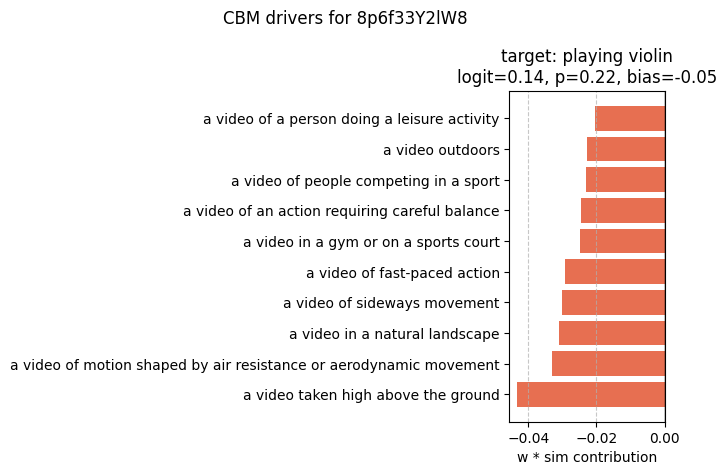

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


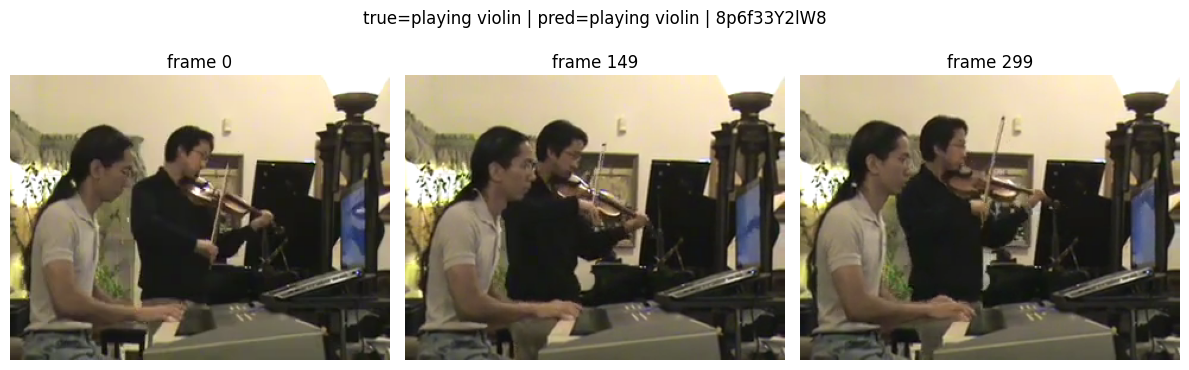

In [ ]:
# TODO make a credible function, create examples
TARGET_CLASS = CLASSES_TO_KEEP[0]
print("target class:", TARGET_CLASS)
N_TOP_CONCEPTS = 10
N_FRAMES = 3
SEED = 42

rng = np.random.default_rng(SEED)

# Map class name -> class index
class_idx = subset_class_names.index(TARGET_CLASS)

# Pick one random matched example from that class
candidate_idx = np.where(labels == class_idx)[0]
chosen_idx = int(rng.choice(candidate_idx))

chosen_name = Path(str(subset_vision_names[chosen_idx])).stem
path_by_stem = {Path(video_path).stem: video_path for video_path, _ in dset._labeled_videos}
video_path = path_by_stem[chosen_name]

print("class:", TARGET_CLASS)
print("chosen idx:", chosen_idx)
print("video stem:", chosen_name)
print("video path:", video_path)

# Concept scores for this example
x_np = sims[chosen_idx].astype(np.float32)

# Linear CBM decomposition: logit_c = bias_c + sum_i w_{c,i} * sim_i
linear = trainer.cbm_model.bottleneck.to(trainer.device).eval()
W = linear.weight.detach().cpu().numpy()
b = linear.bias.detach().cpu().numpy()

with torch.no_grad():
    x = torch.from_numpy(x_np[None]).float().to(trainer.device)
    logits_t = linear(x)[0].detach().cpu()
    probs = logits_t.softmax(dim=0).numpy()
    logits = logits_t.numpy()

pred_idx = int(np.argmax(probs))
pred_class = subset_class_names[pred_idx]

print(f"\nPrediction: {pred_class} ({probs[pred_idx]:.3f})")
print(f"Target prob: {TARGET_CLASS} ({probs[class_idx]:.3f})")

print("\nTop class probabilities:")
for i in np.argsort(-probs)[:5]:
    print(f"{subset_class_names[i]:20s} {probs[i]:.3f}")

focus = [("target", class_idx)]
if pred_idx != class_idx:
    focus.append(("pred", pred_idx))

contrib = {tag: W[idx] * x_np for tag, idx in focus}

# Choose a compact shared set of concepts to visualize
cand = np.unique(np.concatenate([
    # np.argsort(-np.abs(contrib[tag]))[:N_TOP_CONCEPTS]
    np.argsort(contrib[tag])[:N_TOP_CONCEPTS]
    for tag, _ in focus
]))
# importance = np.max(np.stack([np.abs(contrib[tag][cand]) for tag, _ in focus], axis=0), axis=0)
importance = np.max(np.stack([contrib[tag][cand] for tag, _ in focus], axis=0), axis=0)
sel = cand[np.argsort(-importance)[:N_TOP_CONCEPTS]]

print("\nTop decision drivers:")
if len(focus) == 1:
    tag, idx = focus[0]
    for i in sel:
        print(
            f"{concept_list[i]:38.38s}  "
            f"sim={x_np[i]:+.3f}  w={W[idx, i]:+.3f}  contrib={contrib[tag][i]:+.3f}"
        )
else:
    for i in sel:
        print(
            f"{concept_list[i]:30.30s}  sim={x_np[i]:+.3f}  "
            f"true={contrib['target'][i]:+7.3f}  pred={contrib['pred'][i]:+7.3f}"
        )

# Plot compact contribution view
ncols = len(focus)
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4.8), sharey=True)
if ncols == 1:
    axes = [axes]

labels_plot = [concept_list[i] for i in sel][::-1]

for ax, (tag, idx) in zip(axes, focus):
    vals = contrib[tag][sel][::-1]
    colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in vals]
    ax.barh(labels_plot, vals, color=colors)
    ax.axvline(0, color="black", lw=1)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)

    # for y, i, v in zip(range(len(sel)), sel[::-1], vals):
    #     ax.text(
    #         v + (0.01 if v >= 0 else -0.01),
    #         y,
    #         f"s={x_np[i]:+.2f}, w={W[idx, i]:+.2f}",
    #         va="center",
    #         ha="left" if v >= 0 else "right",
    #         fontsize=8,
    #     )

    class_name = subset_class_names[idx]
    ax.set_title(
        f"{tag}: {class_name}\n"
        f"logit={logits[idx]:.2f}, p={probs[idx]:.2f}, bias={b[idx]:+.2f}"
    )
    ax.set_xlabel("w * sim contribution")

plt.suptitle(f"CBM drivers for {chosen_name}")
plt.tight_layout()
plt.show()

# Load full video and show evenly spaced frames
frames, _, info = torchvision.io.read_video(video_path, pts_unit="sec")
num_frames = len(frames)
frame_idx = np.linspace(0, num_frames - 1, N_FRAMES, dtype=int)

fig, axes = plt.subplots(1, N_FRAMES, figsize=(4 * N_FRAMES, 4))
if N_FRAMES == 1:
    axes = [axes]

for ax, fi in zip(axes, frame_idx):
    ax.imshow(frames[fi].numpy())
    ax.set_title(f"frame {fi}")
    ax.axis("off")

plt.suptitle(f"true={TARGET_CLASS} | pred={pred_class} | {chosen_name}")
plt.tight_layout()
plt.show()


### Test

In [17]:
# Data paths
K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

# ----------------------------------------
with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

labeled_video_paths = load_k400_split(
    "test",
    K400_ROOT / "test/1/videos_val",
    class_to_idx=class_to_idx,
    labels_path=Path(K400_ROOT / "test/1/kinetics400_val_list_videos.txt")
)

subset_paths_test, test_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

dset_test = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths_test,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print("Size of test dataset:", len(dset_test))


Size of test dataset: 299


Once again, it is convenient to load representations rather than computing them from scratch. You can run your own separately, or download our representations from [Hugginface](rodrigo-paganini/ttc-videomaeb-viclip-representations-k400).

In [ ]:
# Load representations of the test set. You can download them from: rodrigo-paganini/ttc-videomaeb-viclip-representations-k400
test_vision_names = np.load('data/reps_videomae_k400/representations_k400_val_vision_model_names.npy')
test_vision_reps = np.load('data/reps_videomae_k400/representations_k400_val_vision_model_reps.npy')

# ------------------------------------------------------------------------------------
test_name_to_label = {
    Path(video_path).stem: test_old_to_new_index[info["label"]]
    for video_path, info in dset_test._labeled_videos
}

test_matched_idx = np.array([
    i for i, name in enumerate(test_vision_names)
    if Path(str(name)).stem.strip('.mp4') in test_name_to_label
])

test_subset_vision_names = test_vision_names[test_matched_idx]
test_subset_vision_reps = test_vision_reps[test_matched_idx]
test_labels = np.array(
    [test_name_to_label[Path(str(name)).stem] for name in test_subset_vision_names],
    dtype=np.int64,
)

aligned_test_subset_vision_reps = (
    text_to_concept.linear_aligner
    .get_aligned_representation(torch.from_numpy(test_subset_vision_reps).float().to(device))
    .detach()
    .cpu()
    .numpy()
)

test_sims = cbm.get_concept_concept_scores(aligned_test_subset_vision_reps)

loss, acc, y_true, y_pred = trainer.eval(
    concept_scores=test_sims,
    labels=test_labels,
    batch_size=256,
    return_preds=True,
)


/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: divide by zero encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: overflow encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:44: RuntimeWarning: invalid value encountered in matmul
  scores = vision_features @ concept_embeddings.T


Eval loss: 1.658
Eval acc: 0.438


We obtain an Eval CCE Loss of $1.658$ and accuracy of $0.438$. The baseline for these values can be a random inference: $1.19$ and $0.16$ accuracy.

There is some level of learning, but it is also clear that as long as concepts are imperfectly aligned to semantic data, the classification task becomes very hard.

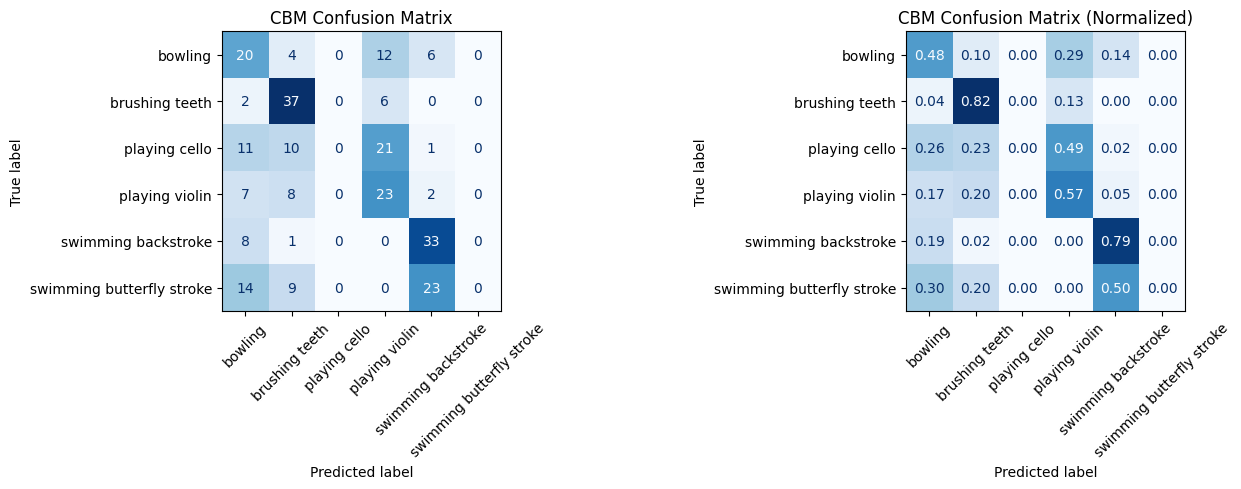

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subset_class_names)
disp.plot(ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
axes[0].set_title("CBM Confusion Matrix")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=subset_class_names)
disp_norm.plot(ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=False, values_format=".2f")
axes[1].set_title("CBM Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()


When looking at the confusion matrix, we see that many failures are coherent:
- Playing cello and Playing violin are confused
- Swimming backstroke and swimming butterfly are confused.